## Phase 2: EDA

### What to do:

- Descriptive Statistics : mean, median, count
- Distribution Analysis : shapes (skewed/symmetrical)
- Outlier Detection : IQR Method and Boxplot
- Correlation Analysis : heatmap, Pearson r
- "So What?" Business Insights : translating the data to get business diagnosis

#### Importing Libraries and Cleaned Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('Dataset_Cleaned.xlsx')
print(df.shape)
df.head()

(1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


#### Descriptive Statistics

In [3]:
print('===Descriptive Statistics===')
df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].describe()

===Descriptive Statistics===


,Quantity,UnitPrice,TotalPrice,ItemsInCart
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,1053.968300,5.485000
std,1.407557,197.177146,819.856558,2.281983
min,1.000000,11.390000,11.390000,1.000000
25%,2.000000,186.062500,410.520000,4.000000
50%,3.000000,364.210000,823.615000,5.000000
75%,4.000000,521.570000,1578.475000,7.000000
max,5.000000,699.930000,3456.400000,10.000000


In [4]:
print('Medians :')
print(df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].median())


Medians :
Quantity         3.000
UnitPrice      364.210
TotalPrice     823.615
ItemsInCart      5.000
dtype: float64


#### Distribution Anlysis

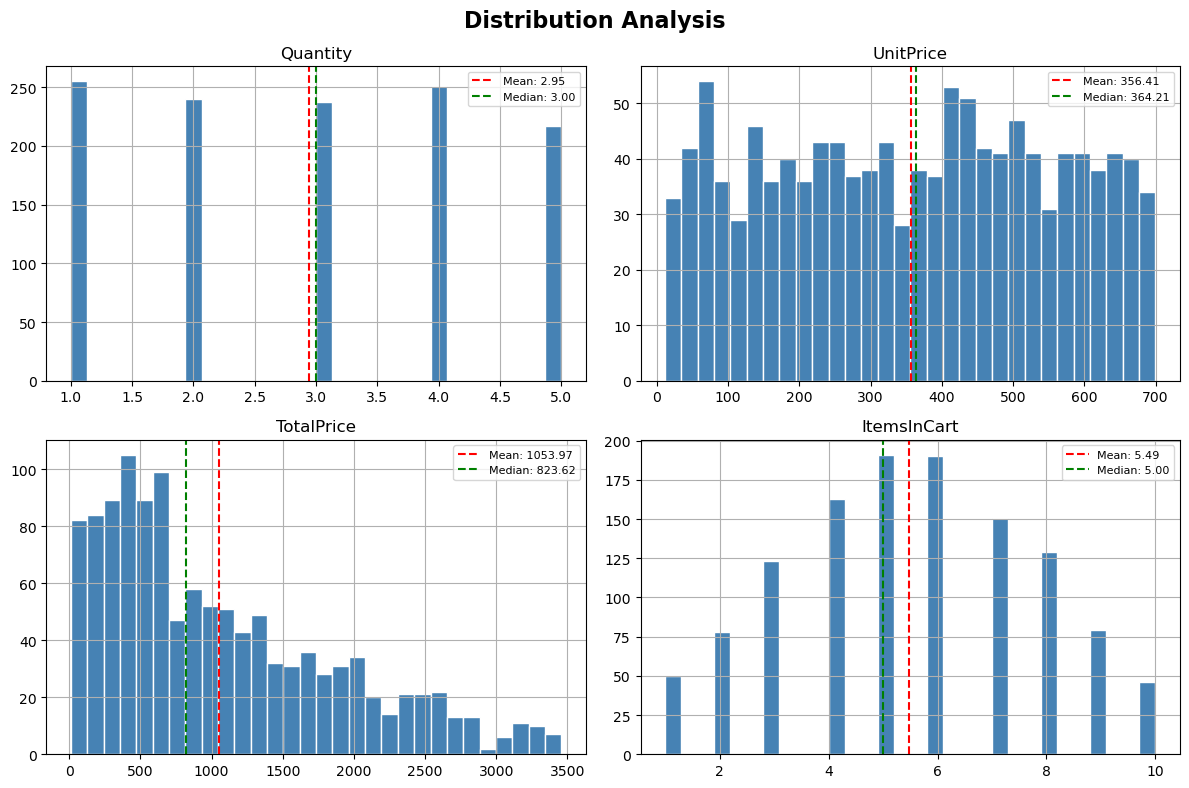

Observation: If Mean > Median = Right Skewed | Mean < Median = Left Skewed


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribution Analysis', fontsize=16, fontweight='bold')

cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']

for i, col in enumerate(cols):
    ax = axes[i//2][i%2]
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.axvline(df[col].mean(), color='red', linestyle='--', 
               label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green', linestyle='--', 
               label=f'Median: {df[col].median():.2f}')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Observation: If Mean > Median = Right Skewed | Mean < Median = Left Skewed")

#### Outlier Detection using IQR

In [6]:
print("=== OUTLIER DETECTION (IQR Method) ===\n")

def detect_outliers_iqr(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}:")
    print(f"   Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"   Valid Range: [{lower:.2f}, {upper:.2f}]")
    print(f"   Outliers Found: {len(outliers)}")
    print()

for col in ['Quantity', 'UnitPrice', 'TotalPrice']:
    detect_outliers_iqr(col)

=== OUTLIER DETECTION (IQR Method) ===

Quantity:
   Q1=2.00, Q3=4.00, IQR=2.00
   Valid Range: [-1.00, 7.00]
   Outliers Found: 0

UnitPrice:
   Q1=186.06, Q3=521.57, IQR=335.51
   Valid Range: [-317.20, 1024.83]
   Outliers Found: 0

TotalPrice:
   Q1=410.52, Q3=1578.47, IQR=1167.95
   Valid Range: [-1341.41, 3330.41]
   Outliers Found: 8



#### Boxplots

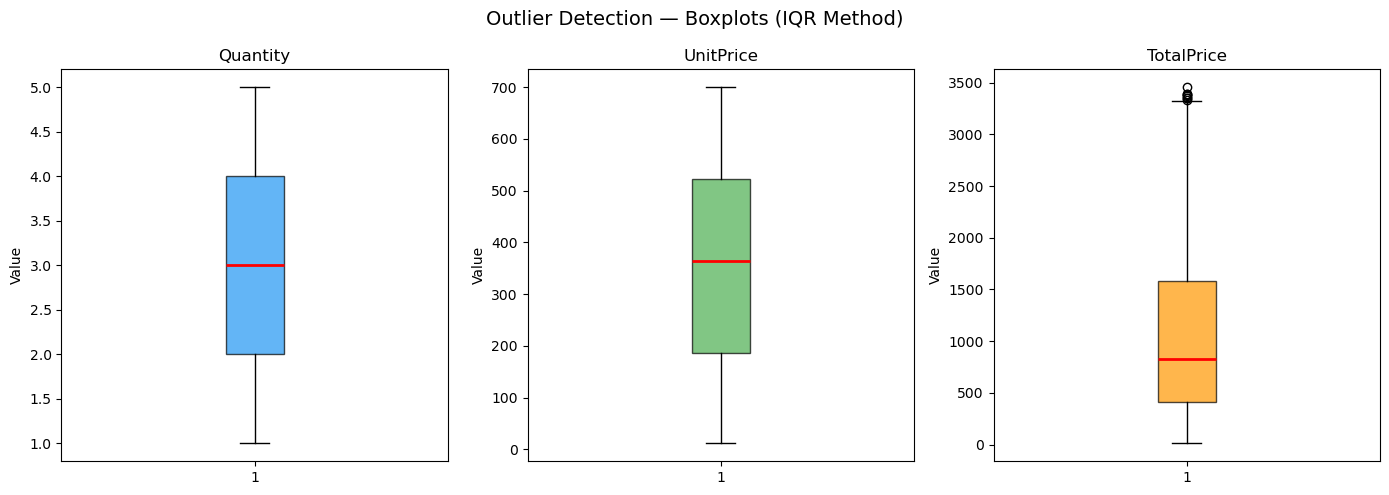

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Outlier Detection - Boxplots (IQR Method)', fontsize=14)

colors = ['#2196F3', '#4CAF50', '#FF9800']
for i, col in enumerate(['Quantity', 'UnitPrice', 'TotalPrice']):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

#### Correlation Heatmap

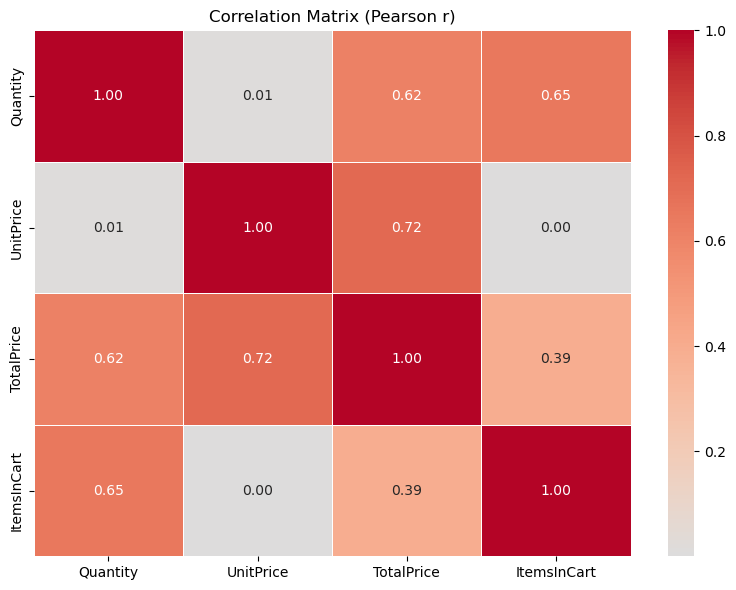

In [8]:
corr = df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Matrix (Pearson r)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

#### "So What?" Business Insights

In [9]:
print("=" * 50)
print("   SO WHAT? — BUSINESS DIAGNOSIS")
print("=" * 50)

total = len(df)
cancelled = df[df['OrderStatus'] == 'Cancelled'].shape[0]
returned  = df[df['OrderStatus'] == 'Returned'].shape[0]
bad_orders = cancelled + returned

print(f"\n{bad_orders} out of {total} orders are Cancelled or Returned")
print(f"   That's {bad_orders/total*100:.1f}% of all orders — revenue leakage risk")

print(f"\nMean (₹{df['TotalPrice'].mean():.0f}) > Median (₹{df['TotalPrice'].median():.0f})")
print(f"   Distribution is RIGHT-SKEWED")
print(f"   Standard marketing will miss the majority low-value segment")

print(f"\n74.2% of customers used a coupon to purchase")
print(f"   Customers are heavily discount-dependent")
print(f"   Risk: removing coupons could drop orders significantly")

print(f"\nInstagram is the #1 acquisition channel (259 orders)")
print(f"   Action: increase Instagram ad spend, reduce underperforming channels")

   SO WHAT? — BUSINESS DIAGNOSIS

497 out of 1200 orders are Cancelled or Returned
   That's 41.4% of all orders — revenue leakage risk

Mean (₹1054) > Median (₹824)
   Distribution is RIGHT-SKEWED
   Standard marketing will miss the majority low-value segment

74.2% of customers used a coupon to purchase
   Customers are heavily discount-dependent
   Risk: removing coupons could drop orders significantly

Instagram is the #1 acquisition channel (259 orders)
   Action: increase Instagram ad spend, reduce underperforming channels


#### Saving the stats

In [ ]:
df.describe().to_excel("EDA_Summary_Stats.xlsx")
print("Summary saved!!")

Summary saved!
